# Assignment 8: Building a Variational Autoencoder and Visualising Its Latent Space

**Objective:** Build a Variational Autoencoder (VAE) using the MNIST dataset, use a **2-dimensional latent space**, train for approximately **20 epochs**, record **Reconstruction Loss** and **KL-Divergence Loss** separately, visualise the latent space, and generate digits from selected latent points.

> Recommended runtime: **GPU** (Google Colab → Runtime → Change runtime type → GPU)

This notebook also includes the practical-demo items: displaying MNIST samples, a small normal Autoencoder comparison, VAE reconstruction, VAE latent-space plot, generated digits across the latent space, and generation from extreme/outside latent points.

## 1. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

np.random.seed(42)
tf.random.set_seed(42)

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Basic Parameters

In [2]:
LATENT_DIM = 2
BATCH_SIZE = 128
AE_EPOCHS = 15
VAE_EPOCHS = 20
LEARNING_RATE = 1e-3

## 3. Load and Prepare the MNIST Dataset

In [3]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize pixel values from 0-255 to 0-1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add channel dimension: (28, 28) -> (28, 28, 1)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print("Training images:", x_train.shape)
print("Test images:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28, 1)
Test images: (10000, 28, 28, 1)


## 4. Display Sample MNIST Images

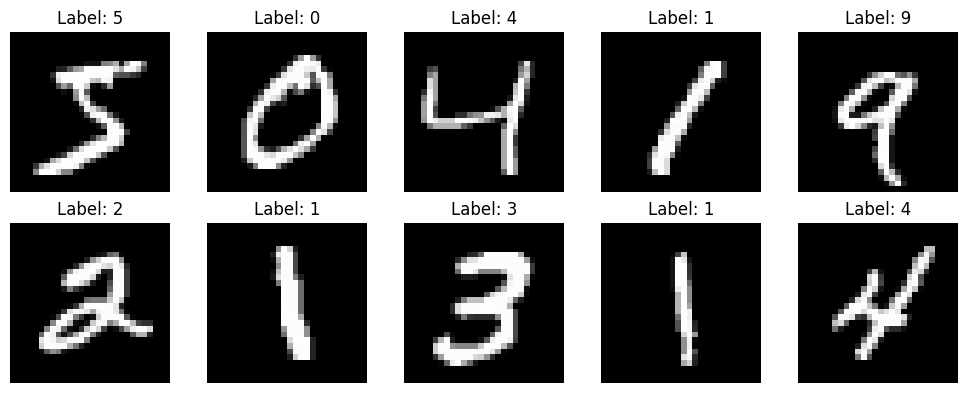

In [4]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

## 5. Normal Autoencoder (Practical Demo Comparison)

A simple Autoencoder is trained first for **15 epochs** using a **sigmoid** output activation.  
This section is included for comparison with the VAE.

In [5]:
# Encoder for normal Autoencoder
ae_input = keras.Input(shape=(28, 28, 1))
x = layers.Flatten()(ae_input)
x = layers.Dense(256, activation="relu")(x)
ae_latent = layers.Dense(2, name="ae_latent")(x)
ae_encoder = keras.Model(ae_input, ae_latent, name="ae_encoder")

# Decoder for normal Autoencoder
ae_latent_input = keras.Input(shape=(2,))
x = layers.Dense(256, activation="relu")(ae_latent_input)
x = layers.Dense(28 * 28, activation="sigmoid")(x)
ae_output = layers.Reshape((28, 28, 1))(x)
ae_decoder = keras.Model(ae_latent_input, ae_output, name="ae_decoder")

# Full Autoencoder
ae_output_full = ae_decoder(ae_encoder(ae_input))
autoencoder = keras.Model(ae_input, ae_output_full, name="autoencoder")

autoencoder.compile(
    optimizer=keras.optimizers.Adam(LEARNING_RATE),
    loss="mse"
)

autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ae_encoder (Functional)         │ (None, 2)              │       201,474 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ae_decoder (Functional)         │ (None, 28, 28, 1)      │       202,256 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 403,730 (1.54 MB)

 Trainable params: 403,730 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
ae_history = autoencoder.fit(
    x_train, x_train,
    epochs=AE_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_test, x_test),
    verbose=1
)

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0645 - val_loss: 0.0542
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0513 - val_loss: 0.0490
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0482 - val_loss: 0.0473
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0468 - val_loss: 0.0463
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0459 - val_loss: 0.0454
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0451 - val_loss: 0.0448
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0444 - val_loss: 0.0442
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0438 - val_loss: 0.0437
Epoch 9/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0433 - val_loss: 0.0433
Epoch 10/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0429 - val_loss: 0.0430
Epoch 11/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0425 - val_loss: 0.0427
Epoch 12/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

### Autoencoder 2D Latent Space

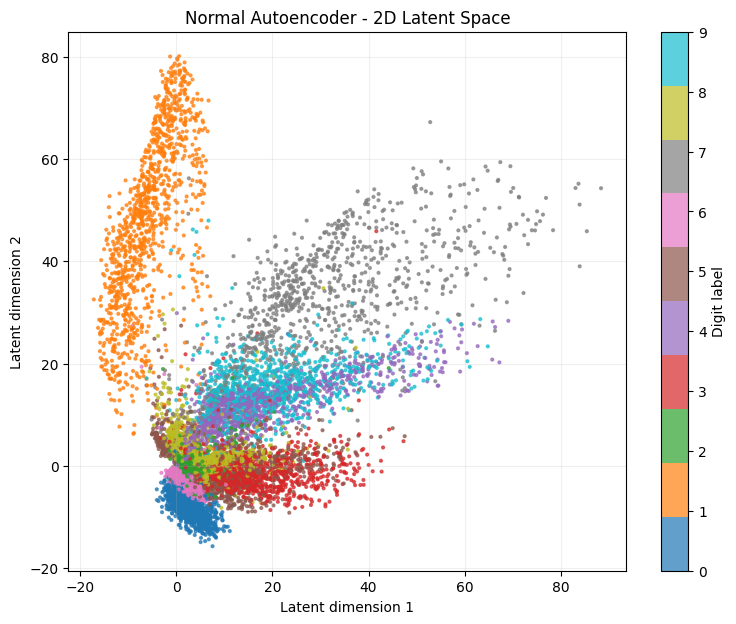

In [7]:
ae_z = ae_encoder.predict(x_test, batch_size=BATCH_SIZE, verbose=0)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(ae_z[:, 0], ae_z[:, 1], c=y_test, cmap="tab10", s=4, alpha=0.7)
plt.colorbar(scatter, ticks=range(10), label="Digit label")
plt.xlabel("Latent dimension 1")
plt.ylabel("Latent dimension 2")
plt.title("Normal Autoencoder - 2D Latent Space")
plt.grid(alpha=0.2)
plt.show()

# Variational Autoencoder (VAE)

## 6. Sampling Layer

The VAE encoder produces:
- **z_mean**
- **z_log_var**
- **z**, sampled using the reparameterization trick.

In [8]:
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

## 7. Build the VAE Encoder

In [9]:
encoder_inputs = keras.Input(shape=(28, 28, 1), name="encoder_input")

x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(128, activation="relu")(x)

z_mean = layers.Dense(LATENT_DIM, name="z_mean")(x)
z_log_var = layers.Dense(LATENT_DIM, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])

encoder = keras.Model(
    encoder_inputs,
    [z_mean, z_log_var, z],
    name="encoder"
)

encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 14, 14,    │        320 │ encoder_input[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 7, 7, 64)  │     18,496 │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 3136)      │          0 │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │    401,536 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        258 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        258 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 420,868 (1.61 MB)

 Trainable params: 420,868 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

## 8. Build the VAE Decoder

In [10]:
latent_inputs = keras.Input(shape=(LATENT_DIM,), name="z_sampling")

x = layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2DTranspose(
    1, 3, activation="sigmoid", padding="same"
)(x)

decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ z_sampling (InputLayer)         │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

## 9. Define VAE Losses

The total VAE loss is:

**Total Loss = Reconstruction Loss + KL-Divergence Loss**

For this notebook:
- Reconstruction Loss = **Mean Squared Error (MSE)**
- KL Loss = regularisation term that encourages a structured latent space

In [11]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data, training=True)
            reconstruction = self.decoder(z, training=True)

            # MSE reconstruction loss, summed over image pixels then averaged over batch
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.square(data - reconstruction),
                    axis=(1, 2, 3)
                )
            )

            # KL divergence
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                    axis=1
                )
            )

            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "total_loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

## 10. Train the VAE for 20 Epochs

In [12]:
vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam(LEARNING_RATE))

vae_history = vae.fit(
    x_train,
    epochs=VAE_EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - kl_loss: 1.8480 - reconstruction_loss: 51.9916 - total_loss: 53.8395
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 3.2518 - reconstruction_loss: 40.0199 - total_loss: 43.2716
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 3.8564 - reconstruction_loss: 36.7757 - total_loss: 40.6322
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 4.1390 - reconstruction_loss: 35.3792 - total_loss: 39.5182
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 4.3190 - reconstruction_loss: 34.5496 - total_loss: 38.8686
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 4.4464 - reconstruction_loss: 33.9613 - total_loss: 38.4077
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 4.5435 - reconstruction_loss: 33.5201 - total_loss: 38.0636
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 4.6349 - reconstruction_loss: 33.1107 - total_loss: 37.7457
Epoch 9/20
469

## 11. Plot Reconstruction Loss, KL-Divergence Loss and Total Loss

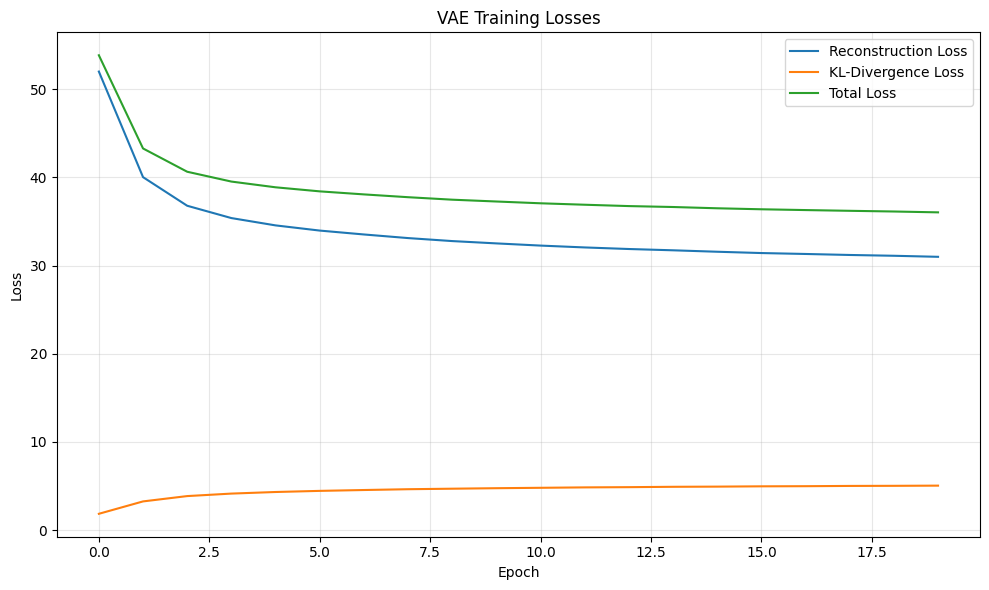

In [13]:
history = vae_history.history

plt.figure(figsize=(10, 6))
plt.plot(history["reconstruction_loss"], label="Reconstruction Loss")
plt.plot(history["kl_loss"], label="KL-Divergence Loss")
plt.plot(history["total_loss"], label="Total Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training Losses")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("vae_training_losses.png", dpi=200, bbox_inches="tight")
plt.show()

## 12. Reconstruction Test: Original Images vs VAE Reconstructions

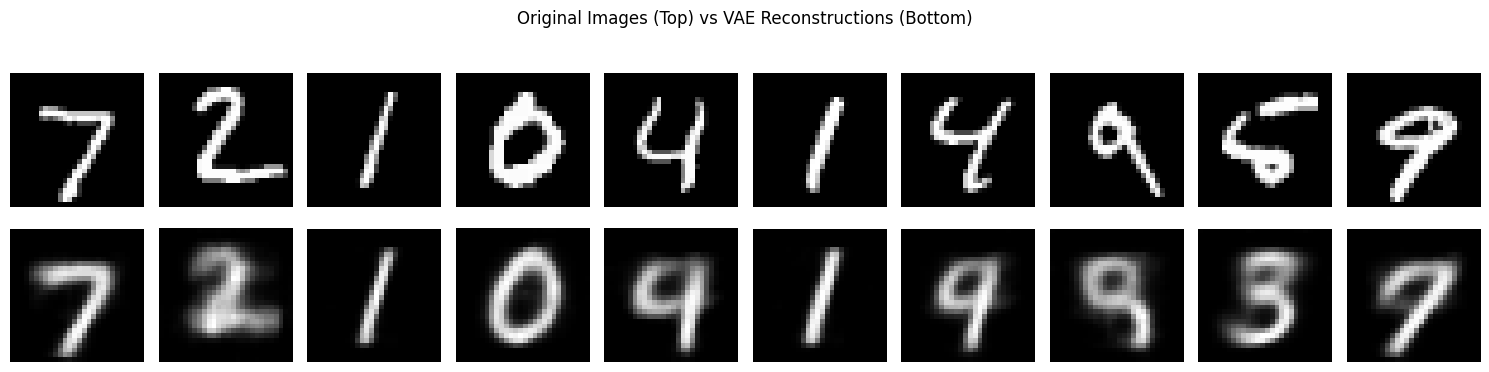

In [14]:
n = 10
z_mean_test, z_log_var_test, z_test = encoder.predict(
    x_test[:n], batch_size=BATCH_SIZE, verbose=0
)
reconstructed = decoder.predict(z_mean_test, verbose=0)

plt.figure(figsize=(15, 4))

for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_ylabel("Original", fontsize=12)

    # Reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed[i].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_ylabel("Reconstructed", fontsize=12)

plt.suptitle("Original Images (Top) vs VAE Reconstructions (Bottom)")
plt.tight_layout()
plt.savefig("vae_reconstruction_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

## 13. VAE 2D Latent Space Scatter Plot

The test images are passed through the encoder.  
Each point represents one MNIST test image.  
Points are coloured according to digit labels **0–9**.

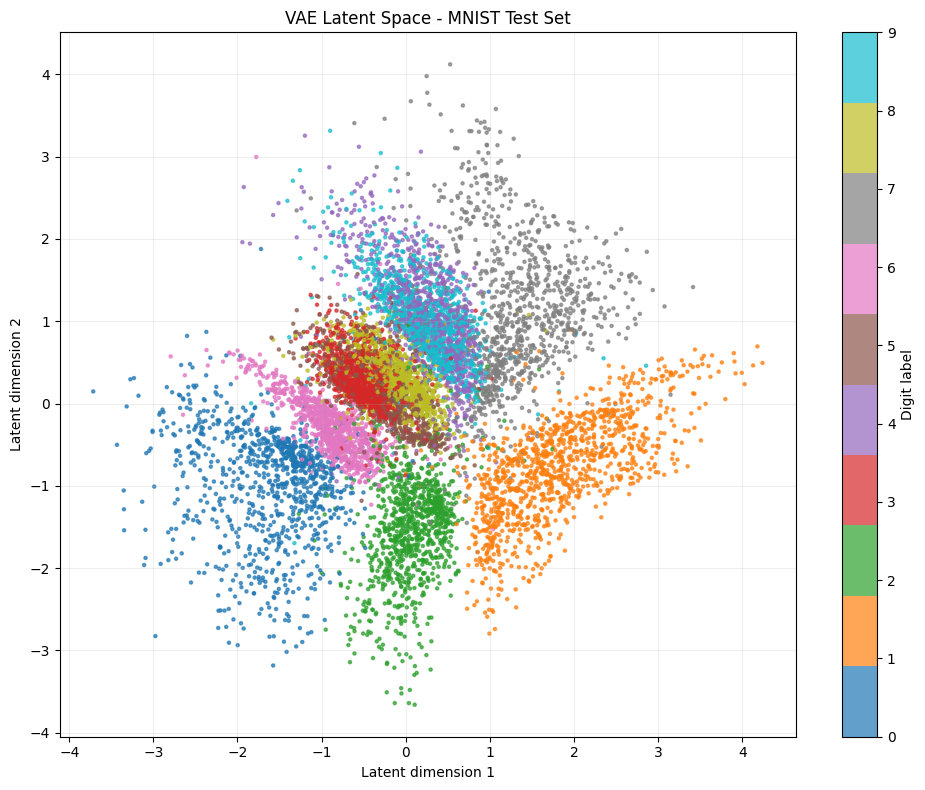

In [15]:
z_mean_test, _, _ = encoder.predict(
    x_test,
    batch_size=BATCH_SIZE,
    verbose=0
)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    z_mean_test[:, 0],
    z_mean_test[:, 1],
    c=y_test,
    cmap="tab10",
    s=5,
    alpha=0.7
)
plt.colorbar(scatter, ticks=range(10), label="Digit label")
plt.xlabel("Latent dimension 1")
plt.ylabel("Latent dimension 2")
plt.title("VAE Latent Space - MNIST Test Set")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("vae_latent_space_scatter.png", dpi=250, bbox_inches="tight")
plt.show()

## 14. Decode Points Across the Latent Space (-3 to +3)

A grid of points is selected across the 2D latent space.  
Moving gradually from one grid position to another lets us observe how generated digits change.

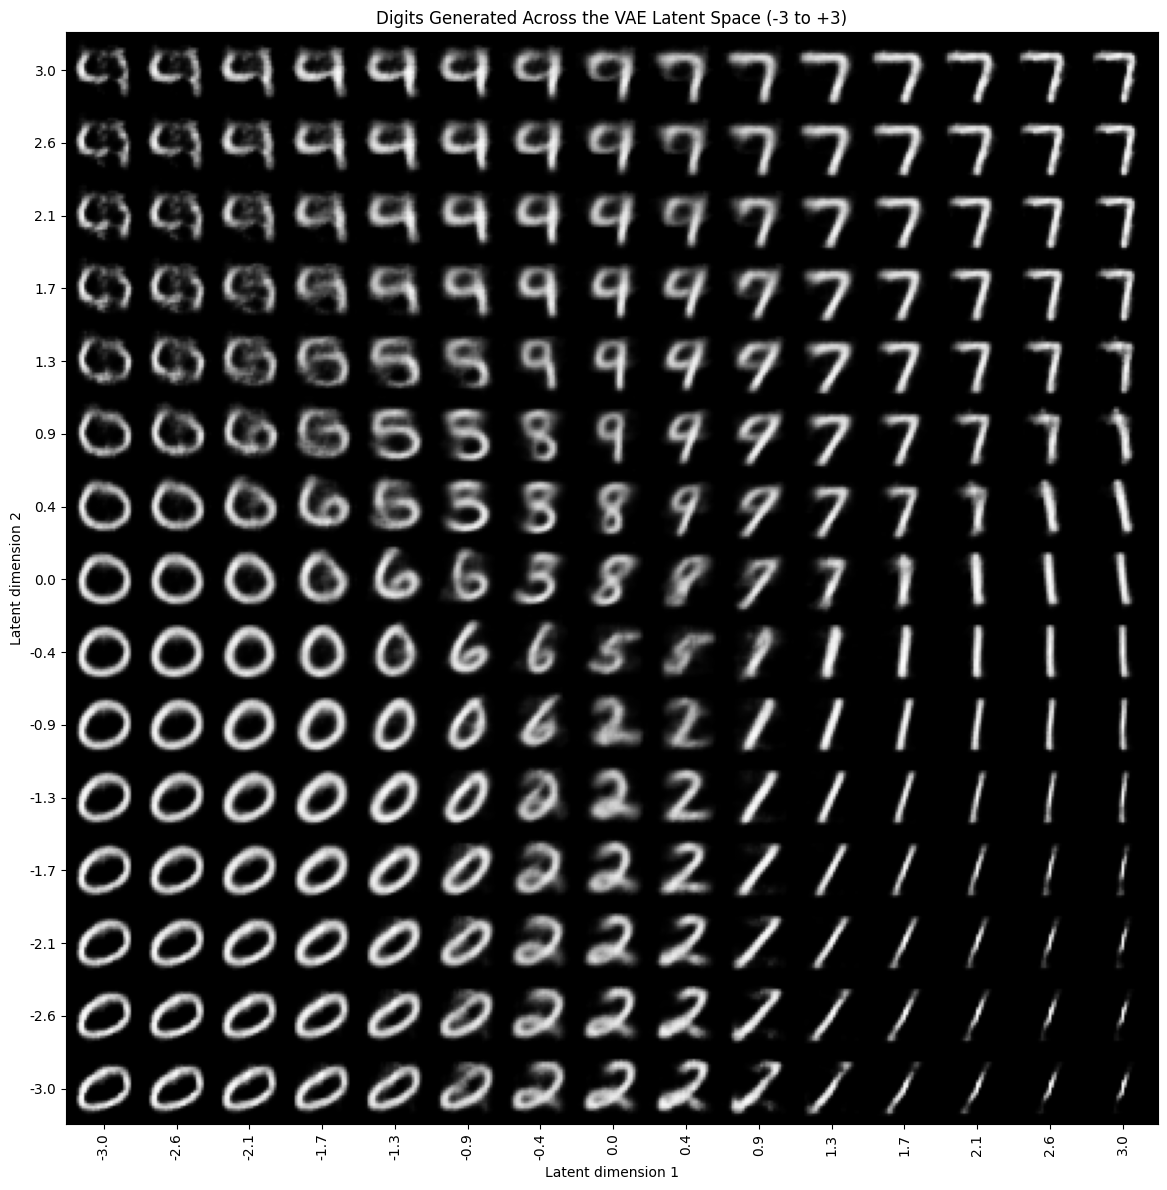

In [16]:
grid_size = 15
grid_x = np.linspace(-3, 3, grid_size)
grid_y = np.linspace(-3, 3, grid_size)

figure = np.zeros((28 * grid_size, 28 * grid_size))

for i, yi in enumerate(grid_y[::-1]):
    for j, xi in enumerate(grid_x):
        z_sample = np.array([[xi, yi]], dtype=np.float32)
        decoded = decoder.predict(z_sample, verbose=0)[0].squeeze()

        row_start = i * 28
        row_end = (i + 1) * 28
        col_start = j * 28
        col_end = (j + 1) * 28

        figure[row_start:row_end, col_start:col_end] = decoded

plt.figure(figsize=(12, 12))
plt.imshow(figure, cmap="gray")
plt.xticks(
    np.arange(14, 28 * grid_size, 28),
    [f"{x:.1f}" for x in grid_x],
    rotation=90
)
plt.yticks(
    np.arange(14, 28 * grid_size, 28),
    [f"{y:.1f}" for y in grid_y[::-1]]
)
plt.xlabel("Latent dimension 1")
plt.ylabel("Latent dimension 2")
plt.title("Digits Generated Across the VAE Latent Space (-3 to +3)")
plt.tight_layout()
plt.savefig("vae_decoded_image_grid.png", dpi=250, bbox_inches="tight")
plt.show()

## 15. Generate Images from Extreme and Outside Latent Points

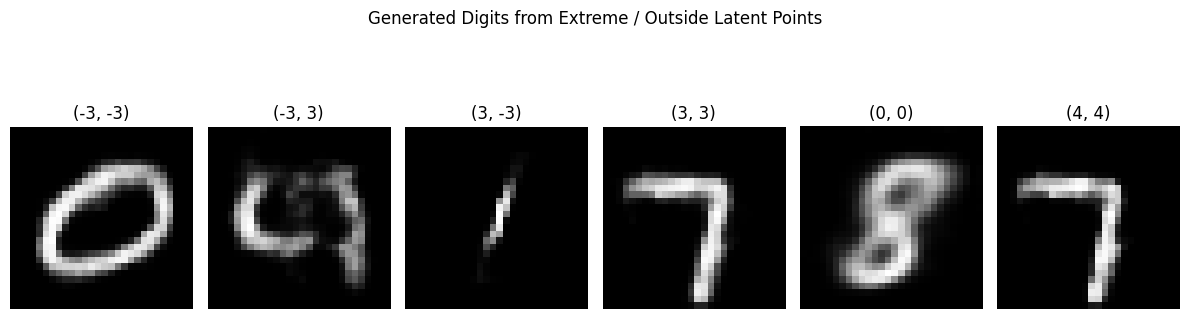

In [17]:
extreme_points = np.array([
    [-3, -3],
    [-3,  3],
    [ 3, -3],
    [ 3,  3],
    [ 0,  0],
    [ 4,  4],   # outside the main -3 to +3 region
], dtype=np.float32)

generated = decoder.predict(extreme_points, verbose=0)

plt.figure(figsize=(12, 4))
for i, point in enumerate(extreme_points):
    plt.subplot(1, len(extreme_points), i + 1)
    plt.imshow(generated[i].squeeze(), cmap="gray")
    plt.title(f"({point[0]:.0f}, {point[1]:.0f})")
    plt.axis("off")

plt.suptitle("Generated Digits from Extreme / Outside Latent Points")
plt.tight_layout()
plt.savefig("vae_extreme_latent_points.png", dpi=200, bbox_inches="tight")
plt.show()

# 16. Short Written Observations

### 1. Do similar digits form clusters?
Yes. After training, images belonging to the same or visually similar digit classes usually appear close to one another in the 2D latent space. For example, samples of the same digit tend to occupy related regions instead of being completely random.

### 2. Are the clusters clearly separated?
The clusters are **partly separated**, but not perfectly. Some classes overlap because the latent space has only two dimensions and some handwritten digits have similar shapes. This overlap is normal in a 2D VAE.

### 3. How do generated digits change when moving gradually through the latent space?
When the latent coordinates are changed gradually, the decoded image also changes gradually. A digit shape can slowly become thicker, thinner, more curved, or start resembling another digit.

### 4. Does the transition between generated images appear smooth?
Yes. One important property of a VAE is that nearby latent points usually decode into similar images. Therefore, the generated digit grid should show relatively smooth transitions rather than sudden random changes.

### 5. What happens at extreme or outside latent points?
Points far away from the well-populated latent region may produce less clear or unusual digit shapes. This happens because the decoder has seen fewer training examples corresponding to those extreme regions.

## Conclusion
The 2D Variational Autoencoder learns a compact and structured representation of MNIST digits. The latent scatter plot demonstrates grouping of similar digits, while the decoded grid shows that the learned latent space is continuous enough to generate smooth changes between digit-like images.